# Final Plots

Mounted at /content/drive


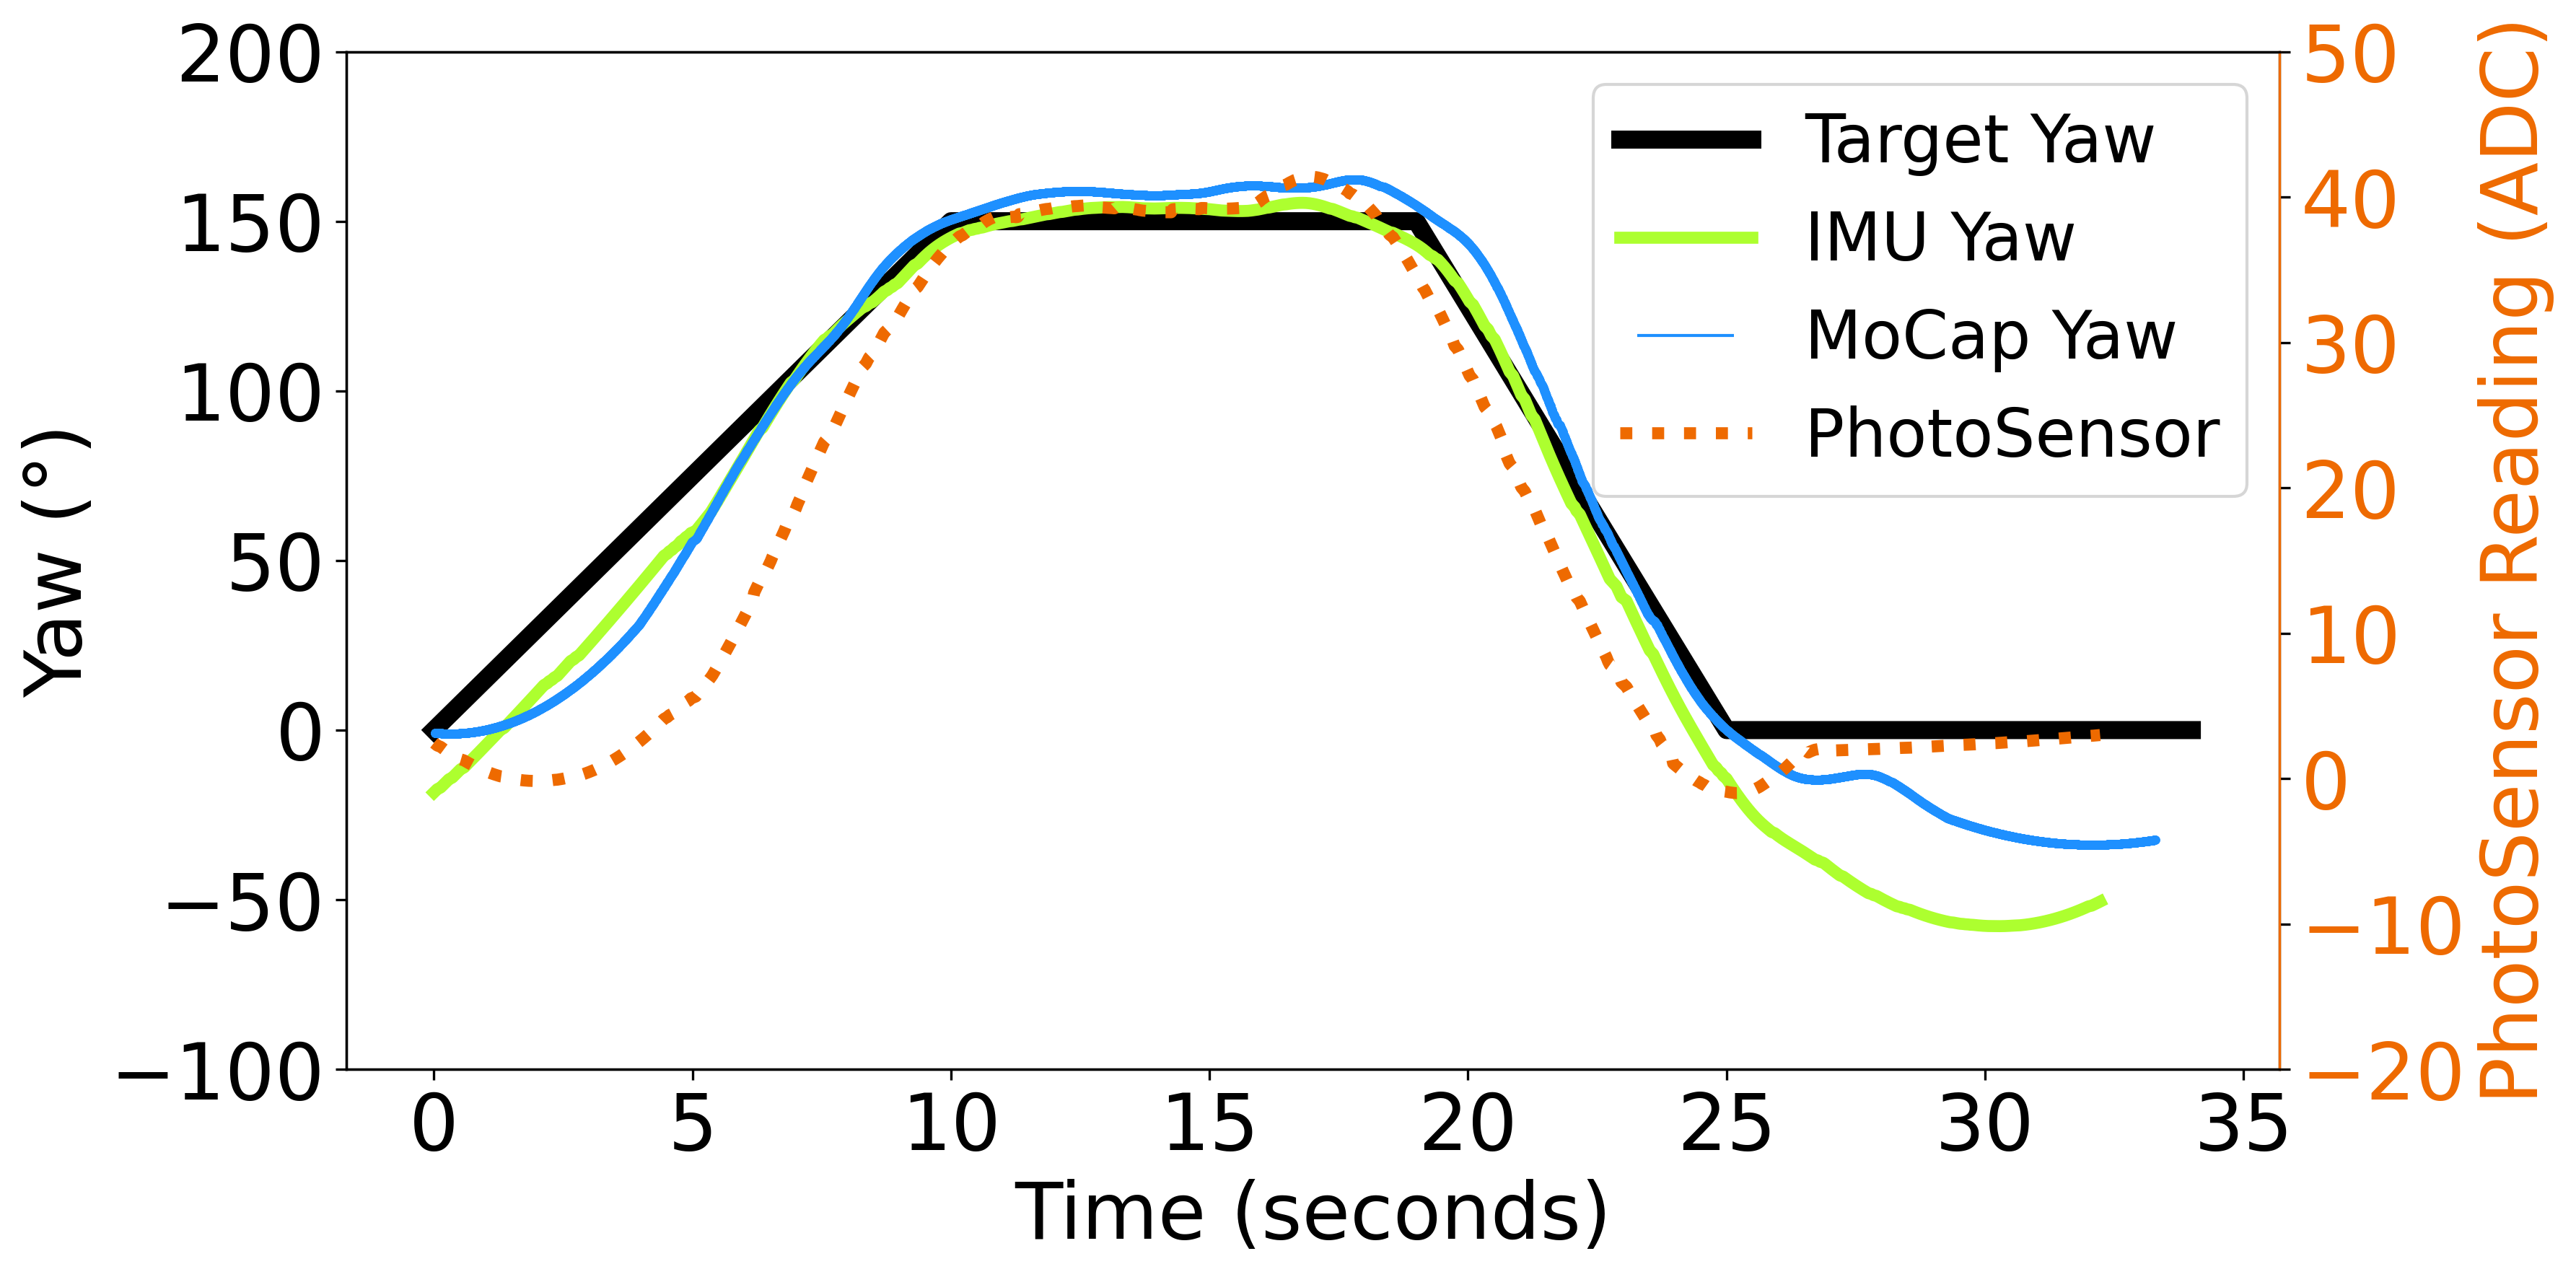

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.transform import Rotation as R
from scipy.signal import savgol_filter, medfilt

# ================================
# Data Reading Functions
# ================================
def read_imu_data(file_path):
    return pd.read_csv(file_path)

def read_mocap_data(file_path):
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()

        header_line = None
        for idx, line in enumerate(lines):
            if 'Frame' in line and 'Time' in line:
                header_line = idx
                break

        if header_line is None:
            print("Header not found in the file.")
            return pd.DataFrame()

        data = pd.read_csv(
            file_path,
            skiprows=header_line + 1,
            header=None,
            usecols=range(10),
            engine='python',
            sep=',',
            skipinitialspace=True
        )
        data.columns = ['Frame', 'Time', 'X', 'Y', 'Z', 'W', 'Pos_X', 'Pos_Y', 'Pos_Z', 'Marker_Error']

        for col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')

        return data.dropna(subset=['X', 'Y', 'Z', 'W']).reset_index(drop=True)
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")
        return pd.DataFrame()

# ================================
# Data Cleaning Functions
# ================================
def remove_spikes_median_filter(df, column_name, window_size=5):
    try:
        df[column_name + '_filtered'] = medfilt(df[column_name], kernel_size=window_size)
        return df
    except Exception as e:
        print(f"Error in removing spikes: {e}")
        return df

def remove_outliers_zscore(df, column_name, threshold=3):
    z_scores = np.abs(stats.zscore(df[column_name]))
    return df[z_scores < threshold].reset_index(drop=True)

def remove_outliers_iqr(df, column_name, factor=1.5):
    try:
        Q1 = df[column_name].quantile(0.25)
        Q3 = df[column_name].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        return df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)].reset_index(drop=True)
    except Exception as e:
        print(f"Error in IQR outlier removal: {e}")
        return df

def trim_data(df, start_index, end_index):
    return df.iloc[start_index:end_index].reset_index(drop=True)

# ================================
# Data Transformation Functions
# ================================
def smooth_data(df, column_name, method='rolling', window_size=11, polyorder=2):
    try:
        if method == 'rolling':
            df[column_name] = df[column_name].rolling(window=window_size, center=True).mean()
        elif method == 'savgol':
            df[column_name] = savgol_filter(df[column_name], window_length=window_size, polyorder=polyorder)
        return df
    except Exception as e:
        print(f"Error in smoothing data: {e}")
        return df

def calculate_imu_yaw(df, dt):
    df['Yaw'] = np.cumsum(df['GyroX'] * dt)
    return df

def quaternion_to_yaw(df):
    try:
        df[['X', 'Y', 'Z', 'W']] = df[['X', 'Y', 'Z', 'W']].astype(float)
        quats = df[['X', 'Y', 'Z', 'W']].to_numpy()
        rotations = R.from_quat(quats)
        euler_angles = rotations.as_euler('xzy', degrees=True)
        df['Yaw'] = euler_angles[:, 2]
        return df
    except Exception as e:
        print(f"An error occurred in quaternion_to_yaw: {e}")
        return df

# ================================
# Settings and File Paths
# ================================
# imu_file_paths = [ # Kyle
#     '/content/drive/MyDrive/University of Washington/UW_Research/Projects/Coin-copter/Science_Robotics_2025/Figures/Figure4/Yaw-control_with_light-sensor_graphs/sensor-yaw-tests/YCLST2-IMU.CSV'
# ]
# mocap_file_paths = [ # Kyle
#     '/content/drive/MyDrive/University of Washington/UW_Research/Projects/Coin-copter/Science_Robotics_2025/Figures/Figure4/Yaw-control_with_light-sensor_graphs/sensor-yaw-tests/yclsT2-mocap.csv'
# ]
imu_file_paths = [ # Vicente
    '/content/drive/MyDrive/sensor-yaw-tests/YCLST2-IMU.CSV'
]
mocap_file_paths = [ # Vicente
    '/content/drive/MyDrive/sensor-yaw-tests/yclsT2-mocap.csv'
]

imu_sample_rate = 31
imu_dt = 1 / imu_sample_rate

smoothing_method = 'savgol'
smoothing_window_size = 301
mocap_smoothing_window_size = 1901
savgol_polyorder = 2
outlier_factor = 1.5
spike_kernel_size = 9
photo_col_name = 'PhotoResistor'

imu_indices = [(0, 1000)]
mocap_indices = [(600, 8400)]

yaw_ylim = None
photosensor_ylim = None

imu_x_shifts = [0]
imu_y_shifts = [0]

mocap_x_shifts = [-2.5]
mocap_y_shifts = [-17]

photosensor_y_shifts = [0, 0, 0]  # Not used in this one-file example

# ================================
# Process Data
# ================================
imu_data_list = []
for idx, imu_file in enumerate(imu_file_paths):
    df_imu = read_imu_data(imu_file)
    if not df_imu.empty:
        df_imu = calculate_imu_yaw(df_imu, imu_dt)
        df_imu['Time'] = df_imu['DataPoint'] * imu_dt
        start_idx, end_idx = imu_indices[idx]
        df_imu = trim_data(df_imu, start_idx, end_idx)
        if photo_col_name in df_imu.columns:
            df_imu = remove_spikes_median_filter(df_imu, photo_col_name)
            df_imu = remove_outliers_iqr(df_imu, photo_col_name, factor=outlier_factor)
            df_imu = smooth_data(df_imu, photo_col_name, method=smoothing_method,
                                 window_size=smoothing_window_size, polyorder=savgol_polyorder)
        else:
            print(f"Column '{photo_col_name}' not found in {imu_file}")
        df_imu = remove_outliers_iqr(df_imu, 'Yaw', factor=outlier_factor)
        df_imu = smooth_data(df_imu, 'Yaw', method=smoothing_method,
                             window_size=smoothing_window_size, polyorder=savgol_polyorder)
        imu_data_list.append(df_imu)
    else:
        print(f"No data available for IMU file: {imu_file}")

mocap_data_list = []
for idx, mocap_file in enumerate(mocap_file_paths):
    df_mocap = read_mocap_data(mocap_file)
    if not df_mocap.empty:
        df_mocap = quaternion_to_yaw(df_mocap)
        start_idx, end_idx = mocap_indices[idx]
        df_mocap = trim_data(df_mocap, start_idx, end_idx)
        df_mocap = remove_outliers_iqr(df_mocap, 'Yaw', factor=outlier_factor)
        df_mocap = smooth_data(df_mocap, 'Yaw', method=smoothing_method,
                               window_size=mocap_smoothing_window_size, polyorder=savgol_polyorder)
        mocap_data_list.append(df_mocap)
    else:
        print(f"No data available for mocap file: {mocap_file}")

# ================================
# Helper Functions for Plotting
# ================================
def align_zeros_no_clipping(ax1, ax2, data_min=None, data_max=None):
    """
    Align y=0 on ax2 with y=0 on ax1 in pixel space,
    then expand ax2 if needed to show [data_min, data_max].
    """
    fig = ax1.figure
    fig.canvas.draw()
    # Convert (0,0) in ax1 to display, then back to ax2:
    _, y_disp_zero_ax1 = ax1.transData.transform((0, 0))
    _, zero_mapped_ax2 = ax2.transData.inverted().transform((0, y_disp_zero_ax1))
    y_min_ax2, y_max_ax2 = ax2.get_ylim()
    shift = -zero_mapped_ax2
    ax2.set_ylim(y_min_ax2 + shift, y_max_ax2 + shift)
    # Expand ax2 if necessary:
    if data_min is not None and data_max is not None:
        current_min, current_max = ax2.get_ylim()
        new_min = data_min if data_min < current_min else current_min
        new_max = data_max if data_max > current_max else current_max
        ax2.set_ylim(new_min, new_max)

def asymmetric_limits_from_data(data, buffer_ratio=0.01):
    """
    Compute y-limits that include all data (and 0), with a small buffer.
    These limits can be asymmetric if the data is not symmetric about 0.
    """
    dmin = np.min(data)
    dmax = np.max(data)
    dmin = min(dmin, 0)
    dmax = max(dmax, 0)
    margin = (dmax - dmin) * buffer_ratio
    return dmin - margin, dmax + margin

# ================================
# Main Plotting Loop
# ================================
for idx in range(len(imu_file_paths)):
    plt.figure(figsize=(12, 6),dpi=300)
    ax1 = plt.gca()
    ax1.set_xlabel('Time (seconds)', fontsize=26)
    ax1.set_ylabel('Yaw (°)', color='black', fontsize=26)
    ax1.tick_params(axis='both', labelsize=26)

    # ----------------------------
    # Add Command Yaw (brown line)
    # ----------------------------
    # Define time segments for the piecewise command yaw signal:
    t1 = np.linspace(0, 10, 100)           # ramp from 0s to 10s
    t2 = np.linspace(10, 19, 50)           # constant from 10s to 19s
    t3 = np.linspace(19, 25, 100)          # ramp from 19s to 25s
    t4 = np.linspace(25, 34, 50)           # constant from 25s to 34s

    # Define corresponding yaw values:
    y1 = np.linspace(0, 150, 100)          # from -50° to 150° over ramp
    y2 = 150 * np.ones_like(t2)              # constant at 150°
    y3 = np.linspace(150, 0, 100)            # from 150° to 0° over ramp
    y4 = 0 * np.ones_like(t2)              # constant at 0°

    # Concatenate segments:
    t_command = np.concatenate((t1, t2, t3, t4))
    yaw_command = np.concatenate((y1, y2, y3, y4))

    # Plot the command yaw line:
    ax1.plot(t_command, yaw_command, label='Target Yaw',
             color='Black', linestyle='-', linewidth=6) # #653700

    # Plot IMU Yaw data on ax1
    df_imu = imu_data_list[idx]
    x_shift = imu_x_shifts[idx]
    y_shift = imu_y_shifts[idx]
    yaw_data = df_imu['Yaw'] + y_shift
    x_data = df_imu['Time'] + x_shift
    ax1.plot(x_data, yaw_data, label='IMU Yaw',
             color='greenyellow', linewidth=4)

    # (Optional) Plot Mocap Yaw on ax1 if available:
    mocap_idx = None
    if idx == 0:
        mocap_idx = 0
    elif idx == 2:
        mocap_idx = 1
    if mocap_idx is not None and mocap_idx < len(mocap_data_list):
        df_mocap = mocap_data_list[mocap_idx]
        x_shift_mocap = mocap_x_shifts[mocap_idx]
        y_shift_mocap = mocap_y_shifts[mocap_idx]
        x_data_mocap = df_mocap['Time'] + x_shift_mocap
        y_data_mocap = -df_mocap['Yaw'] + y_shift_mocap
        ax1.plot(x_data_mocap, y_data_mocap, label='MoCap Yaw',
                 color='dodgerblue', marker='.', linestyle='None', markersize=4)

    # Set asymmetric limits for ax1 based on yaw data
    if yaw_ylim is not None:
        ax1.set_ylim(yaw_ylim)
    else:
        new_yaw_limits = asymmetric_limits_from_data(yaw_data, buffer_ratio=0.01)
        ax1.set_ylim(new_yaw_limits)

    # Create secondary axis for PhotoSensor data
    ax2 = ax1.twinx()
    # Set right axis label to orange (only the label and spine)
    ax2.set_ylabel('PhotoSensor Reading (ADC)', color='#EE6A00', fontsize=26)
    ax2.spines['right'].set_color('#EE6A00')
    # (Do NOT change tick label colors so the numbers remain default.)
    ax2.tick_params(axis='both', labelsize=26)
    ax2.tick_params(axis='y', labelcolor='#EE6A00')

    # Plot PhotoSensor data
    if photo_col_name in df_imu.columns:
        x_shift_photo = imu_x_shifts[idx]
        y_shift_photo = photosensor_y_shifts[idx]
        x_data_photo = df_imu['Time'] + x_shift_photo
        photo_data = df_imu[photo_col_name] + y_shift_photo
        ax2.plot(x_data_photo, photo_data, label='PhotoSensor',
                 color='#EE6A00', linestyle=':', linewidth=4)
        if photosensor_ylim is not None:
            ax2.set_ylim(photosensor_ylim)
        else:
            new_photo_limits = asymmetric_limits_from_data(photo_data, buffer_ratio=0.01)
            ax2.set_ylim(new_photo_limits)

    # Align the zero lines of ax1 and ax2
    if photo_col_name in df_imu.columns:
        align_zeros_no_clipping(ax1, ax2,
                                data_min=ax2.get_ylim()[0],
                                data_max=ax2.get_ylim()[1])

    # Ensure that 0 is a visible tick on both axes.
    ax1.set_yticks(sorted(set(ax1.get_yticks().tolist() + [0])))
    ax2.set_yticks(sorted(set(ax2.get_yticks().tolist() + [0])))

    # Combine legends from both axes.
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize = 22)
    # Increase marker size for the 'Mocap Yaw' entry only.
    legend = ax1.get_legend()
    for handle, text in zip(legend.legend_handles, legend.get_texts()):
        if text.get_text() == 'MoCap Yaw':
            handle.set_marker("_")     # Set desired marker type for the legend
            handle.set_markersize(32)  # Set desired marker size for the legend
    # ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
    # plt.title('Yaw and PhotoSensor Reading vs Time')
    plt.tight_layout()
    plt.show()

Average Yaw Error (IMU vs MoCap): 11.74°


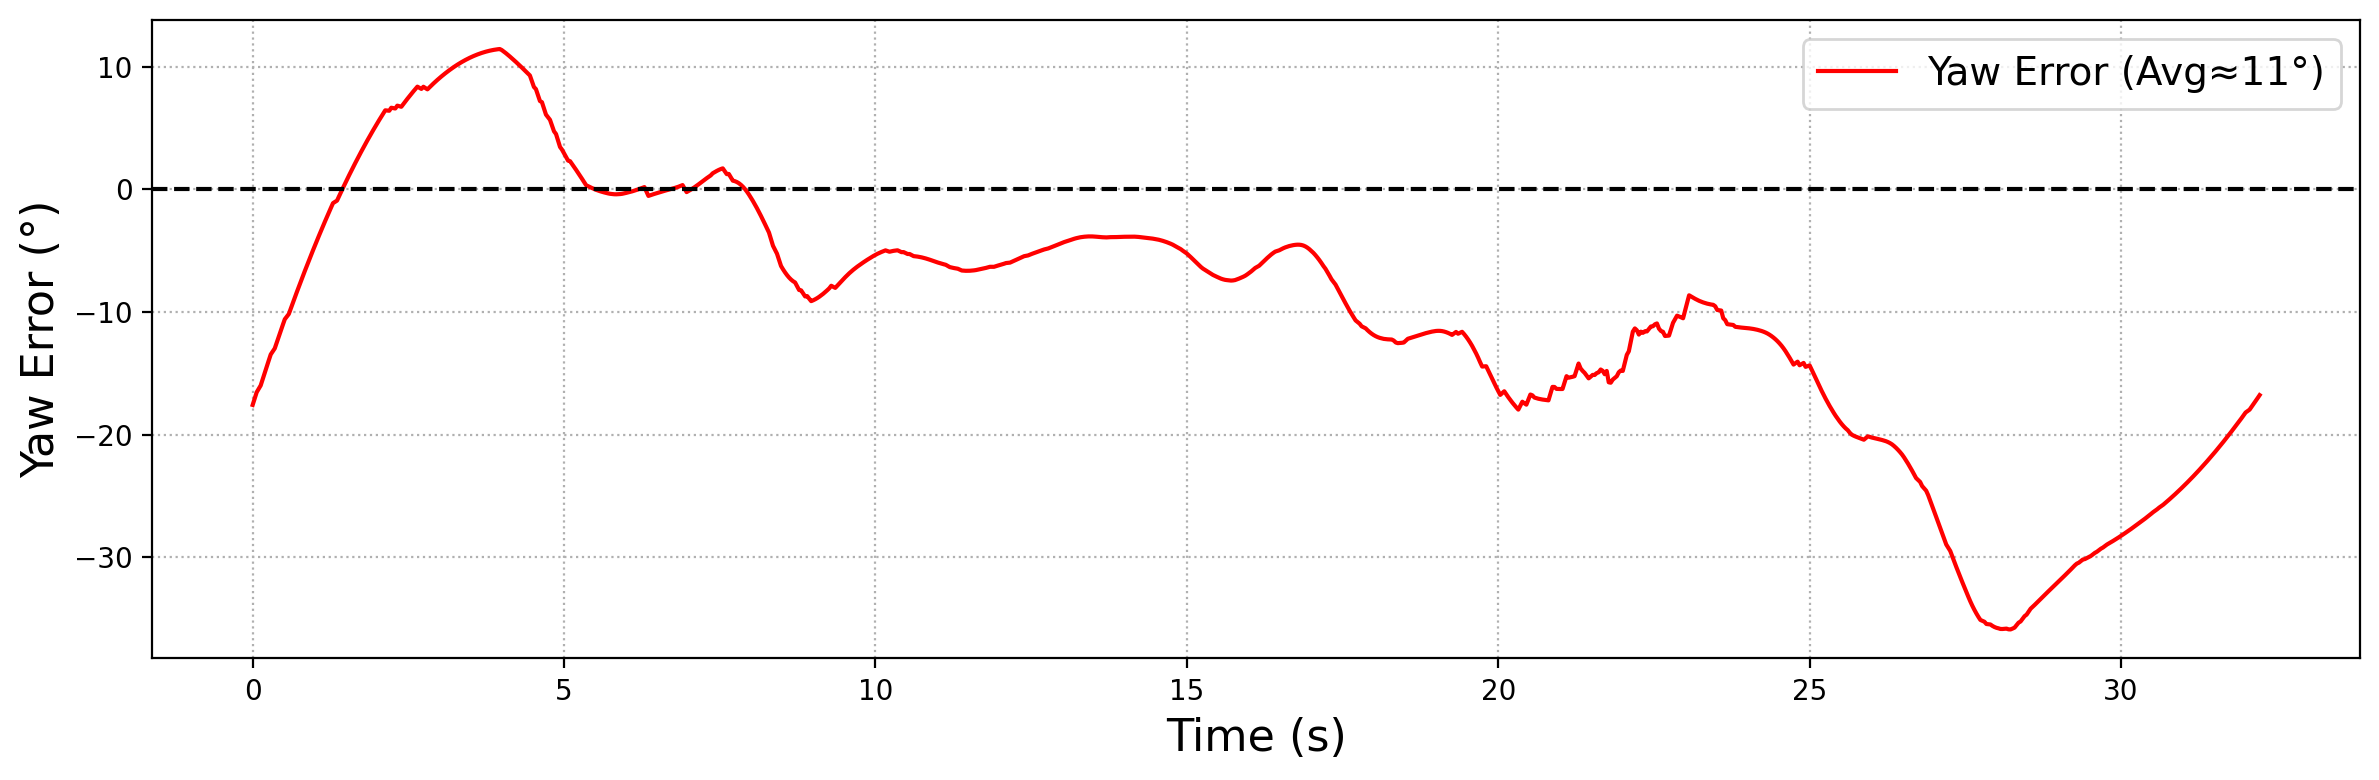

In [ ]:
# Semayat & Giannah's code for calculating IMU and MoCap yaw error
# ================================
# Calculate Average Yaw Error
# ================================

def calculate_average_yaw_error(df_imu, df_mocap, x_shift_imu=0, y_shift_imu=0,
                                x_shift_mocap=0, y_shift_mocap=0, invert_mocap=True):
    """
    Calculates the average yaw error between IMU and MoCap yaw data.
    Assumes IMU and MoCap yaw are already preprocessed & trimmed.
    """
    # Apply shifts
    imu_time = df_imu['Time'].to_numpy() + x_shift_imu
    imu_yaw = df_imu['Yaw'].to_numpy() + y_shift_imu

    mocap_time = df_mocap['Time'].to_numpy() + x_shift_mocap
    mocap_yaw = df_mocap['Yaw'].to_numpy()
    if invert_mocap:
        mocap_yaw = -mocap_yaw
    mocap_yaw = mocap_yaw + y_shift_mocap

    # Interpolate MoCap yaw to IMU timestamps
    mocap_yaw_interp = np.interp(imu_time, mocap_time, mocap_yaw)

    # Compute yaw error (difference)
    yaw_error = imu_yaw - mocap_yaw_interp

    # Compute average absolute error
    avg_error = np.mean(np.abs(yaw_error))

    return avg_error, yaw_error, imu_time


# ================================
# Run Error Calculation
# ================================

# Example: first dataset
if imu_data_list and mocap_data_list:
    avg_error, yaw_error, imu_time = calculate_average_yaw_error(
        imu_data_list[0],
        mocap_data_list[0],
        x_shift_imu=imu_x_shifts[0],
        y_shift_imu=imu_y_shifts[0],
        x_shift_mocap=mocap_x_shifts[0],
        y_shift_mocap=mocap_y_shifts[0],
        invert_mocap=True
    )

    print(f"Average Yaw Error (IMU vs MoCap): {avg_error:.2f}°")

    # Optional: plot error vs time
    plt.figure(figsize=(12,4), dpi=200)
    plt.plot(imu_time, yaw_error, color='red', label=f'Yaw Error (Avg≈{int(avg_error):.0f}°)')
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('Time (s)', fontsize=16)
    plt.ylabel('Yaw Error (°)', fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    plt.show()